#  Postcards & Profit
## Eight cities. Six years. And the question nobody in the travel 
industry is asking with data: can you see a city's moment coming 
before it arrives?

---

There is a specific kind of person who has seventeen tabs open 
about a city they are not visiting for another eight months. Who 
researches neighbourhoods the way other people research people. 
Who knows the difference between a city that is having a moment 
and a city that has become a feeling and understands that only 
one of them lasts.

This project is written by that person. 

Cities are the world's most powerful brands and the least 
understood ones. Paris didn't become Paris because of a marketing 
campaign. Seoul didn't become the most searched city of its 
generation because someone decided it should. These things happen 
at the intersection of culture, timing, and a convergence of 
signals that the travel industry mostly notices after the fact 
when the flights are full, the hotels are expensive, and the 
locals are tired of seeing the same content creator on every 
corner.

This project uses six years of Google Trends search interest 
across eight cities from the reliably iconic to the quietly 
rising alongside international tourist arrival data to ask 
the question the industry keeps missing: does the data know 
before the crowds do?

---

**Cities:** Paris · New York · Tokyo · Seoul · Lisbon · 
Dubai · Medellín · Mexico City
**Data:** Google Trends 2020–2025 · UN Tourism International 
Arrivals 2019–2023
**Tools:** Python · pandas · Plotly · NumPy · scipy
**Analyst:** Trupthi Raj

In [13]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
os.makedirs('charts', exist_ok=True)

# === CITY COLOURS ===
city_colors = {
    'Paris'      : '#D4537E',
    'New York'   : '#534AB7',
    'Tokyo'      : '#FF6B6B',
    'Seoul'      : '#1D9E75',
    'Lisbon'     : '#BA7517',
    'Dubai'      : '#E8A838',
    'Medellín'   : '#2196F3',
    'Mexico City': '#888780',
    'Rome': '#C4A800'
}

# === LOAD GOOGLE TRENDS ===
cities = {
    'Paris'      : 'data/paris.csv',
    'New York'   : 'data/new_york.csv',
    'Tokyo'      : 'data/tokyo.csv',
    'Seoul'      : 'data/seoul.csv',
    'Lisbon'     : 'data/lisbon.csv',
    'Dubai'      : 'data/dubai.csv',
    'Medellín'   : 'data/medellin.csv',
    'Mexico City': 'data/mexico_city.csv',
    'Rome'       : 'data/rome.csv'
}

dfs = []
for city, path in cities.items():
    df = pd.read_csv(path, skiprows=1)
    df.columns = ['Month', 'Interest']
    df['City'] = city
    df['Month'] = pd.to_datetime(df['Month'])
    df['Interest'] = pd.to_numeric(df['Interest'], errors='coerce')
    dfs.append(df)

df_trends = pd.concat(dfs, ignore_index=True)
df_trends = df_trends.dropna(subset=['Interest'])
df_trends = df_trends[df_trends['Month'] >= '2020-01-01'].copy()
df_trends = df_trends.sort_values(['City', 'Month']).reset_index(drop=True)

print(f"Google Trends rows: {len(df_trends):,}")
print(f"\nCities: {df_trends['City'].unique().tolist()}")
print(f"\nDate range: {df_trends['Month'].min()} → {df_trends['Month'].max()}")
print(f"\nInterest range per city:")
print(df_trends.groupby('City')['Interest'].agg(['min', 'max', 'mean']).round(1))

# === LOAD TOURIST ARRIVALS ===
df_tourism = pd.read_csv('data/tourist_arrivals.csv')
print(f"\n\nTourist arrivals columns: {list(df_tourism.columns)}")
print(f"Shape: {df_tourism.shape}")
print(df_tourism.head(3))

city_list_all = ['Paris', 'New York', 'Tokyo', 'Seoul',
                 'Lisbon', 'Dubai', 'Medellín', 'Mexico City', 'Rome']

city_list = ['Paris', 'New York', 'Tokyo', 'Seoul',
             'Lisbon', 'Dubai', 'Medellín', 'Mexico City']

Google Trends rows: 648

Cities: ['Dubai', 'Lisbon', 'Medellín', 'Mexico City', 'New York', 'Paris', 'Rome', 'Seoul', 'Tokyo']

Date range: 2020-01-01 00:00:00 → 2025-12-01 00:00:00

Interest range per city:
             min  max  mean
City                       
Dubai         36  100  66.1
Lisbon        23  100  53.3
Medellín      68  100  82.6
Mexico City   56  100  79.2
New York      57  100  66.8
Paris         27  100  49.1
Rome          41  100  60.0
Seoul         22  100  39.5
Tokyo          6  100  20.3


Tourist arrivals columns: ['Entity', 'Code', 'Year', 'Arrivals of tourists from abroad']
Shape: (5241, 4)
    Entity Code  Year  Arrivals of tourists from abroad
0  Albania  ALB  2007                         1062000.0
1  Albania  ALB  2008                         1247000.0
2  Albania  ALB  2009                         1711000.0


## Act 1 — The City Map

Search interest is not the same as footfall. It is something 
more useful, 
it is intent before the decision is made. The 
person who searches "things to do in Medellín" at 11pm on a 
Tuesday has not booked a flight yet. But they are thinking 
about it. And when 82.6 million people a month are thinking 
about Medellín — consistently, across five years, that is 
not a travel trend. That is a cultural shift.

Six years of cultural shifts across eight cities is about to 
tell you more about where the world wants to go than five years 
of tourism board reports ever could. The COVID dip is visible 
in every chart. The recovery is not equal. And the annotations 
tell you exactly what was happening in culture every time a 
city spiked because every spike has a reason, and the reason 
is almost never what the tourism board planned for.

Eight cities. Seventy-two months. Every spike has a story.

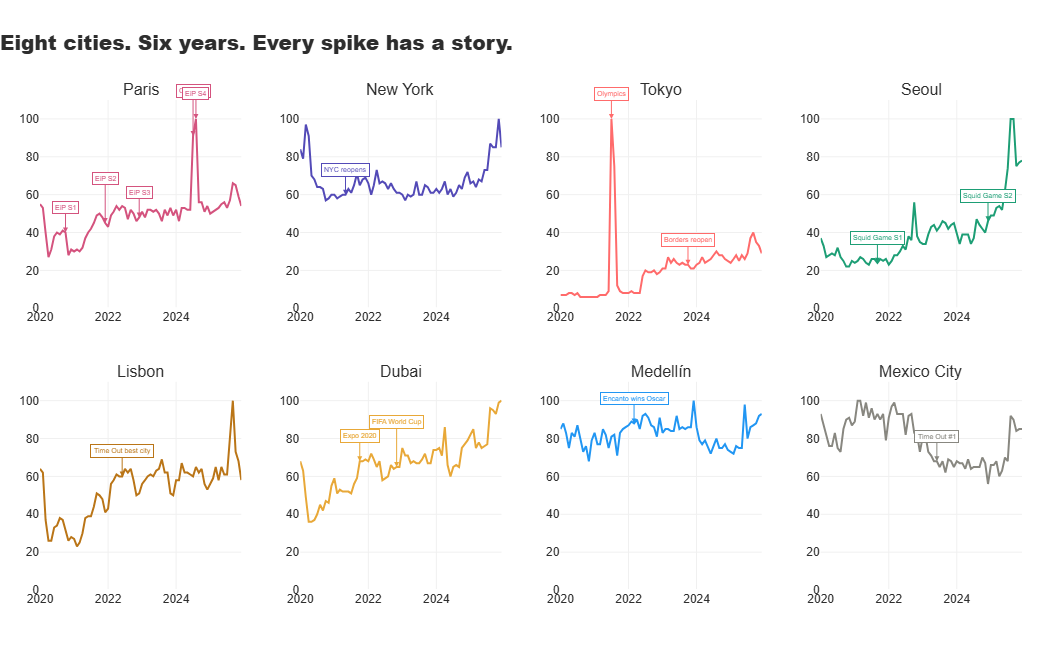

Chart 1 saved.


In [14]:
# === CHART 1: THE CITY MAP ===

events_dict = {
    'Paris': [
        {'date': '2020-10-01', 'label': 'EiP S1', 'ay': -25},
        {'date': '2021-12-01', 'label': 'EiP S2', 'ay': -45},
        {'date': '2022-12-01', 'label': 'EiP S3', 'ay': -25},
        {'date': '2024-07-01', 'label': 'Olympics', 'ay': -45},
        {'date': '2024-08-01', 'label': 'EiP S4', 'ay': -25},
    ],
    'Seoul': [
        {'date': '2021-09-01', 'label': 'Squid Game S1', 'ay': -25},
        {'date': '2024-12-01', 'label': 'Squid Game S2', 'ay': -25},
    ],
    'Tokyo': [
        {'date': '2021-07-01', 'label': 'Olympics', 'ay': -25},
        {'date': '2023-10-01', 'label': 'Borders reopen', 'ay': -25},
    ],
    'Dubai': [
        {'date': '2021-10-01', 'label': 'Expo 2020', 'ay': -25},
        {'date': '2022-11-01', 'label': 'FIFA World Cup', 'ay': -45},
    ],
    'Medellín': [
        {'date': '2022-03-01', 'label': 'Encanto wins Oscar', 'ay': -25},
    ],
    'Mexico City': [
        {'date': '2023-06-01', 'label': "Time Out #1", 'ay': -25},
    ],
    'Lisbon': [
        {'date': '2022-06-01', 'label': "Time Out best city", 'ay': -25},
    ],
    'New York': [
        {'date': '2021-05-01', 'label': 'NYC reopens', 'ay': -25},
    ]
}
city_list = ['Paris', 'New York', 'Tokyo', 'Seoul',
             'Lisbon', 'Dubai', 'Medellín', 'Mexico City']

positions = {
    'Paris'      : (1, 1),
    'New York'   : (1, 2),
    'Tokyo'      : (1, 3),
    'Seoul'      : (1, 4),
    'Lisbon'     : (2, 1),
    'Dubai'      : (2, 2),
    'Medellín'   : (2, 3),
    'Mexico City': (2, 4)
}

fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=city_list,
    horizontal_spacing=0.06,
    vertical_spacing=0.15
)

for city in city_list:
    row, col = positions[city]
    color = city_colors[city]
    city_data = df_trends[df_trends['City'] == city].copy()

    fig.add_trace(go.Scatter(
        x=city_data['Month'],
        y=city_data['Interest'],
        mode='lines',
        name=city,
        line=dict(color=color, width=2),
        showlegend=False,
        hovertemplate=(
            f"<b>{city}</b><br>"
            "Month: %{x|%B %Y}<br>"
            "Interest: %{y}<extra></extra>"
        )
    ), row=row, col=col)

    if city in events_dict:
        for event in events_dict[city]:
            event_date = pd.to_datetime(event['date'])
            match = city_data[city_data['Month'] == event_date]
            if len(match) == 0:
                continue
            y_val = match['Interest'].values[0]

            fig.add_annotation(
                x=event_date,
                y=y_val,
                text=event['label'],
                showarrow=True,
                arrowhead=2,
                arrowsize=1,
                arrowwidth=1,
                arrowcolor=color,
                font=dict(size=7, color=color, family='Arial'),
                bgcolor='white',
                bordercolor=color,
                borderwidth=1,
                borderpad=2,
                ax=event.get('ax', 0),
                ay=event.get('ay', -30),
                row=row,
                col=col
            )

fig.update_layout(
    title=dict(
        text='Eight cities. Six years. Every spike has a story.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=650,
    margin=dict(l=40, r=40, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=11, family='Arial'),
        namelength=-1
    )
)

fig.update_xaxes(gridcolor='#f0f0f0', tickformat='%Y', dtick='M24')
fig.update_yaxes(gridcolor='#f0f0f0', range=[0, 110])

fig.write_html('charts/chart1_city_map.html')
fig.write_image('charts/chart1_city_map.png',
                width=1400, height=650, scale=2)
fig.show()
print("Chart 1 saved.")

## Act 2 - The Netflix Effect

Nobody in the tourism industry planned for Emily in Paris. 
Nobody at the Paris Convention and Visitors Bureau sat in a 
meeting in 2020 and said "a Netflix show about an American 
who can't speak French is about to become our most effective 
marketing campaign in a decade." It just happened. And then 
it kept happening, four seasons, four spikes, four moments 
where the world collectively decided it wanted to go to Paris.

This is the question nobody in tourism budgeting wants to 
answer: is a Netflix show worth more than a tourism campaign? 
Because if the data says yes and it might then the entire 
logic of destination marketing needs rethinking. The show 
didn't show Paris as it is. It showed Paris as a feeling. 
And feelings, apparently, are extremely searchable.

The same story played out in Seoul. Squid Game Season 1 
dropped in September 2021 and search interest for Seoul 
spiked immediately. Not because the show was set in a 
particularly aspirational version of the city, it was set 
in a deadly children's game but because 142 million 
households watched it and suddenly wanted to know where 
it came from. Culture creates curiosity. Curiosity creates 
searches. Searches precede bookings.

The chart below isolates the Netflix moments for Paris and 
Seoul and measures exactly how much each release moved the 
needle and how long the effect lasted.

=== NETFLIX EFFECT — AVERAGE UPLIFT ===

Paris:
  Emily in Paris S1: 40.0 → 33.0 (uplift: +-7.0)
  Emily in Paris S2: 49.0 → 45.7 (uplift: +-3.3)
  Emily in Paris S3: 49.3 → 49.0 (uplift: +-0.3)
  Emily in Paris S4: 65.0 → 70.7 (uplift: +5.7)

Rome:
  Emily in Paris S4: 55.7 → 61.7 (uplift: +6.0)

Seoul:
  Squid Game S1: 25.0 → 25.0 (uplift: +0.0)
  Squid Game S2: 42.0 → 48.0 (uplift: +6.0)


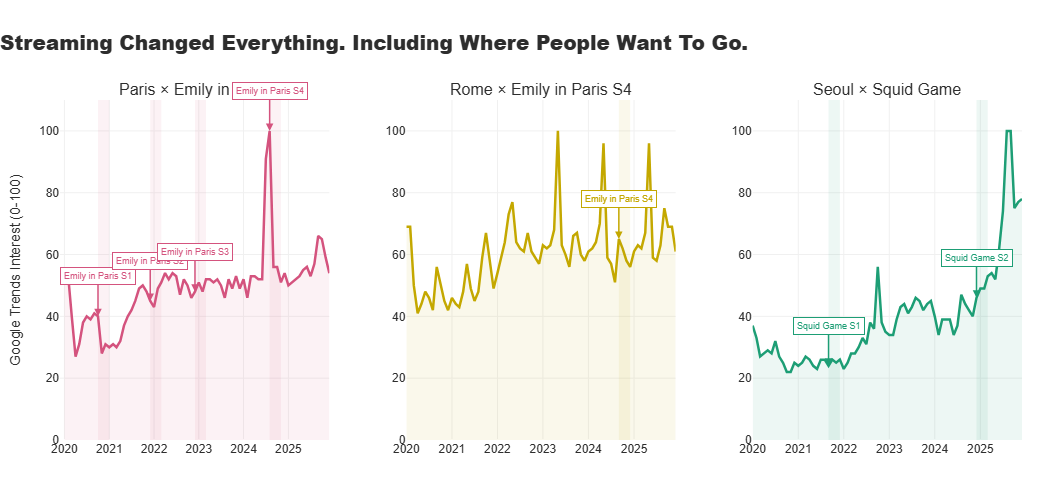


Chart 2 saved.


In [15]:
# === CHART 2: THE NETFLIX EFFECT ===

netflix_events = {
    'Paris': [
        {'date': '2020-10-01', 'label': 'Emily in Paris S1', 'ay': -40},
        {'date': '2021-12-01', 'label': 'Emily in Paris S2', 'ay': -40},
        {'date': '2022-12-01', 'label': 'Emily in Paris S3', 'ay': -40},
        {'date': '2024-08-01', 'label': 'Emily in Paris S4', 'ay': -40},
    ],
    'Rome': [
        {'date': '2024-09-01', 'label': 'Emily in Paris S4', 'ay': -40},
    ],
    'Seoul': [
        {'date': '2021-09-01', 'label': 'Squid Game S1', 'ay': -40},
        {'date': '2024-12-01', 'label': 'Squid Game S2', 'ay': -40},
    ]
}

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        'Paris × Emily in Paris',
        'Rome × Emily in Paris S4',
        'Seoul × Squid Game'
    ],
    horizontal_spacing=0.08
)

for col_idx, city in enumerate(['Paris', 'Rome', 'Seoul']):
    col = col_idx + 1
    color = city_colors[city]
    city_data = df_trends[df_trends['City'] == city].copy()

    fig.add_trace(go.Scatter(
        x=city_data['Month'],
        y=city_data['Interest'],
        mode='lines',
        name=city,
        line=dict(color=color, width=2.5),
        fill='tozeroy',
        fillcolor=f'rgba({int(color[1:3],16)},{int(color[3:5],16)},{int(color[5:7],16)},0.08)',
        showlegend=False,
        hovertemplate=(
            f"<b>{city}</b><br>"
            "Month: %{x|%B %Y}<br>"
            "Interest: %{y}<extra></extra>"
        )
    ), row=1, col=col)

    if city in netflix_events:
        for event in netflix_events[city]:
            event_date = pd.to_datetime(event['date'])
            match = city_data[city_data['Month'] == event_date]
            if len(match) == 0:
                continue
            y_val = match['Interest'].values[0]

            end_date = event_date + pd.DateOffset(months=3)
            fig.add_vrect(
                x0=event_date,
                x1=end_date,
                fillcolor=color,
                opacity=0.08,
                line_width=0,
                row=1, col=col
            )

            fig.add_annotation(
                x=event_date,
                y=y_val,
                text=event['label'],
                showarrow=True,
                arrowhead=2,
                arrowsize=1,
                arrowwidth=1.5,
                arrowcolor=color,
                font=dict(size=9, color=color, family='Arial'),
                bgcolor='white',
                bordercolor=color,
                borderwidth=1,
                borderpad=3,
                ax=0,
                ay=event['ay'],
                row=1, col=col
            )

fig.update_layout(
    title=dict(
        text='Streaming Changed Everything. Including Where People Want To Go.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500,
    margin=dict(l=60, r=40, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.update_xaxes(gridcolor='#f0f0f0', tickformat='%Y', dtick='M12')
fig.update_yaxes(gridcolor='#f0f0f0', range=[0, 110])
fig.update_yaxes(title_text='Google Trends Interest (0-100)', row=1, col=1)

# === UPLIFT CALCULATION ===
print("=== NETFLIX EFFECT — AVERAGE UPLIFT ===")
for city, events in netflix_events.items():
    city_data = df_trends[df_trends['City'] == city].copy()
    print(f"\n{city}:")
    for event in events:
        event_date = pd.to_datetime(event['date'])
        pre = city_data[
            (city_data['Month'] >= event_date - pd.DateOffset(months=3)) &
            (city_data['Month'] < event_date)
        ]['Interest'].mean()
        post = city_data[
            (city_data['Month'] >= event_date) &
            (city_data['Month'] < event_date + pd.DateOffset(months=3))
        ]['Interest'].mean()
        uplift = round(post - pre, 1)
        print(f"  {event['label']}: {pre:.1f} → {post:.1f} (uplift: +{uplift})")

fig.write_html('charts/chart2_netflix_effect.html')
fig.write_image('charts/chart2_netflix_effect.png',
                width=1200, height=500, scale=2)
fig.show()
print("\nChart 2 saved.")

Emily in Paris Season 1 dropped in October 2020 and Paris 
search interest fell by 7 points. Not because nobody watched 
it — 58 million households did in the first month. But because 
the world was in lockdown and search intent requires the belief 
that travel is actually possible. The show created desire. 
The pandemic cancelled the follow-through. By Season 4 in 
August 2024, with borders open and flights cheap, the same 
show delivered a +5.7 uplift. Same content. Different world. 
Completely different data.

Rome never had an Emily in Paris season. It had half of one. 
Season 4 Part 2 moved Emily from Paris to Rome for five 
episodes and Rome's search interest jumped by 6.0 points. 
A show that is not called Emily in Rome, is not set in Rome, 
and does not have Rome in its brand identity moved Rome's 
needle by the same margin as Squid Game moved Seoul's. 
The city did not need to be the star. It just needed a 
cameo in the right story.

Squid Game Season 1 launched in September 2021 to 142 million 
households and Seoul's search uplift was zero. South Korea's 
borders were effectively closed. The cultural moment was 
enormous. The travel intent had nowhere to go. Season 2 in 
December 2024, with open borders and full recovery, delivered 
+6.0. The Netflix Effect is real. But it only works when 
the airport is open.

## Act 3 — The Overtourism Signal

There is a specific kind of city problem that tourism boards 
do not put in their annual reports. It happens when a place 
gets so popular that the people who loved it first stop 
talking about it. When the content gets repetitive. When 
the locals start resenting the cameras. When the city goes 
from discovery to destination to obligation on every travel 
influencer's checklist. The search interest doesn't disappear 
overnight. It plateaus. And then it quietly starts to slide.

Lisbon knows this story. It was named Time Out's best city 
in 2022 and search interest spiked accordingly. Within 
eighteen months locals were protesting in the streets about 
housing costs driven by Airbnb and the government was 
scrambling to regulate short term rentals. The city got 
exactly what it wished for and immediately started 
wondering if it had made a mistake.

The question this analysis asks is whether that plateauing 
is visible in the data before it becomes a headline. 
Can Google Trends show the moment a city tips from 
aspirational to oversaturated? And which cities in this 
dataset are currently showing those early warning signs?

The chart below plots the 12 month rolling average for each 
city to smooth out seasonal noise and reveal the underlying 
trajectory. Rising line means the city is still building. 
Flattening line means it has arrived. Declining line means 
something more interesting is happening.

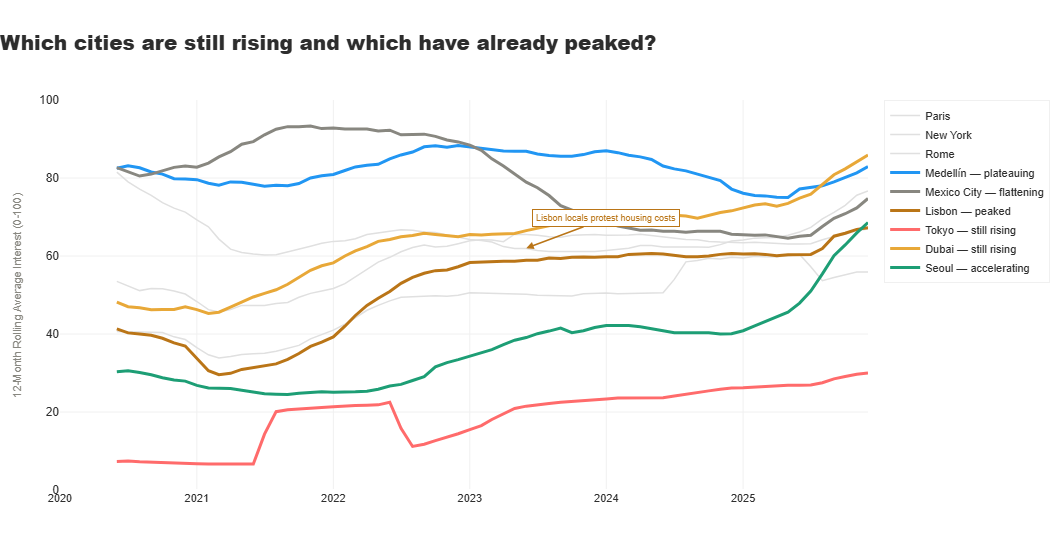

Chart 3 saved.


In [16]:
# === CHART 3: THE OVERTOURISM SIGNAL ===

# Categorise cities
spotlight = {
    'Medellín'   : {'color': city_colors['Medellín'],  'label': 'Medellín — plateauing'},
    'Mexico City': {'color': city_colors['Mexico City'],'label': 'Mexico City — flattening'},
    'Lisbon'     : {'color': city_colors['Lisbon'],     'label': 'Lisbon — peaked'},
    'Tokyo'      : {'color': city_colors['Tokyo'],      'label': 'Tokyo — still rising'},
    'Dubai'      : {'color': city_colors['Dubai'],      'label': 'Dubai — still rising'},
    'Seoul'      : {'color': city_colors['Seoul'],      'label': 'Seoul — accelerating'},
}

background = ['Paris', 'New York', 'Rome']

fig = go.Figure()

# Background cities — grey and thin
for city in background:
    city_data = df_trends[df_trends['City'] == city].copy()
    city_data = city_data.sort_values('Month')
    city_data['rolling_avg'] = city_data['Interest'].rolling(
        window=12, min_periods=6).mean()

    fig.add_trace(go.Scatter(
        x=city_data['Month'],
        y=city_data['rolling_avg'],
        mode='lines',
        name=city,
        line=dict(color='#e0e0e0', width=1.5),
        hovertemplate=(
            f"<b>{city}</b><br>"
            "Month: %{x|%B %Y}<br>"
            "12-month avg: %{y:.1f}<extra></extra>"
        ),
        showlegend=True
    ))

# Spotlight cities — coloured and bold
for city, props in spotlight.items():
    city_data = df_trends[df_trends['City'] == city].copy()
    city_data = city_data.sort_values('Month')
    city_data['rolling_avg'] = city_data['Interest'].rolling(
        window=12, min_periods=6).mean()

    fig.add_trace(go.Scatter(
        x=city_data['Month'],
        y=city_data['rolling_avg'],
        mode='lines',
        name=props['label'],
        line=dict(color=props['color'], width=3),
        hovertemplate=(
            f"<b>{city}</b><br>"
            "Month: %{x|%B %Y}<br>"
            "12-month avg: %{y:.1f}<extra></extra>"
        )
    ))

# Lisbon annotation
fig.add_annotation(
    x='2023-06-01',
    y=62,
    text="Lisbon locals protest housing costs",
    showarrow=True,
    arrowhead=2,
    arrowwidth=1.5,
    arrowcolor=city_colors['Lisbon'],
    font=dict(size=9, color=city_colors['Lisbon'], family='Arial'),
    bgcolor='white',
    bordercolor=city_colors['Lisbon'],
    borderwidth=1,
    borderpad=3,
    ax=80,
    ay=-30
)

fig.update_layout(
    title=dict(
        text='Which cities are still rising and which have already peaked?',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        gridcolor='#f0f0f0',
        tickformat='%Y',
        dtick='M12',
        tickfont=dict(size=11, family='Arial')
    ),
    yaxis=dict(
        title=dict(
            text='12-Month Rolling Average Interest (0-100)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0',
        range=[0, 100]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=550,
    margin=dict(l=60, r=40, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    legend=dict(
        bordercolor='#f0f0f0',
        borderwidth=1,
        font=dict(size=11)
    ),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart3_overtourism_signal.html')
fig.write_image('charts/chart3_overtourism_signal.png',
                width=1200, height=550, scale=2)
fig.show()
print("Chart 3 saved.")

Medellín peaked in 2021 and has been declining ever since. 
The city that went from one of the world's most dangerous 
to one of its most searched did not lose its story. It lost 
its novelty. When everyone has been to Medellín, when every 
travel influencer has done the cable car shot, when the 
neighbourhood that was supposed to be undiscovered has a 
waiting list at its most Instagrammed restaurant, the search 
interest starts to slide. Not because the city got worse. 
Because it got found.

Lisbon's line tells a quieter version of the same story. 
Named Time Out's best city in 2022, search interest climbed 
and then flattened at almost exactly the moment locals started 
protesting in the streets about housing costs driven by short 
term rentals. The tourism board got what it wanted. The city 
got something more complicated.

Tokyo sits at the bottom of this chart for the first two years 
because Japan closed its borders during COVID more strictly 
than almost any other country on earth and kept them closed 
longer. The pink line starting near zero is not low interest. 
It is a locked door. When Japan fully reopened in October 2023 
the line started climbing and has not stopped. Tokyo is not 
declining. Tokyo is just getting started.

Seoul's acceleration from 2024 onwards is Squid Game Season 2 
meeting an open border for the first time. Dubai keeps rising 
because Dubai keeps building reasons to search it. And Mexico 
City, the world's most consistently searched city in this 
dataset, is showing the first signs of a plateau. Not a 
decline. Not yet. But the data noticed.

## Act 4 — The Underdog Index

Tourist arrival data and search interest tell two different 
stories about a city. The arrivals number tells you where 
people actually went. The search interest tells you where 
people wanted to go. The gap between those two things is 
the most commercially interesting number in this analysis.

A city with high search interest and low actual arrivals 
is not an unpopular city. It is an underleveraged one. 
People want to go there. Something is stopping them. 
Maybe the flights are expensive. Maybe the visa is 
complicated. Maybe the infrastructure has not caught up 
with the desire yet. Whatever the reason, that gap 
represents unrealised demand and unrealised demand is 
exactly what a travel brand, a hotel group, or an airline 
looking for the next market should be paying attention to.

The Underdog Index measures exactly this. For each city 
it calculates the ratio of average search interest to 
normalised tourist arrivals. A high score means the city 
is searched significantly more than its actual visitor 
numbers justify. A low score means the arrivals have 
caught up with or exceeded the interest. The cities with 
the highest scores are the ones where the opportunity 
has not yet been captured.

       City  Avg Interest  Arrivals Norm  Underdog Score
      Paris          42.8          100.0           -57.2
       Rome          54.8           67.5           -12.7
   New York          66.4           69.8            -3.4
      Tokyo          14.1            0.1            14.0
     Lisbon          44.0           19.4            24.6
Mexico City          88.3           55.8            32.5
      Dubai          56.5           18.5            37.9
   Medellín          82.9            0.5            82.4


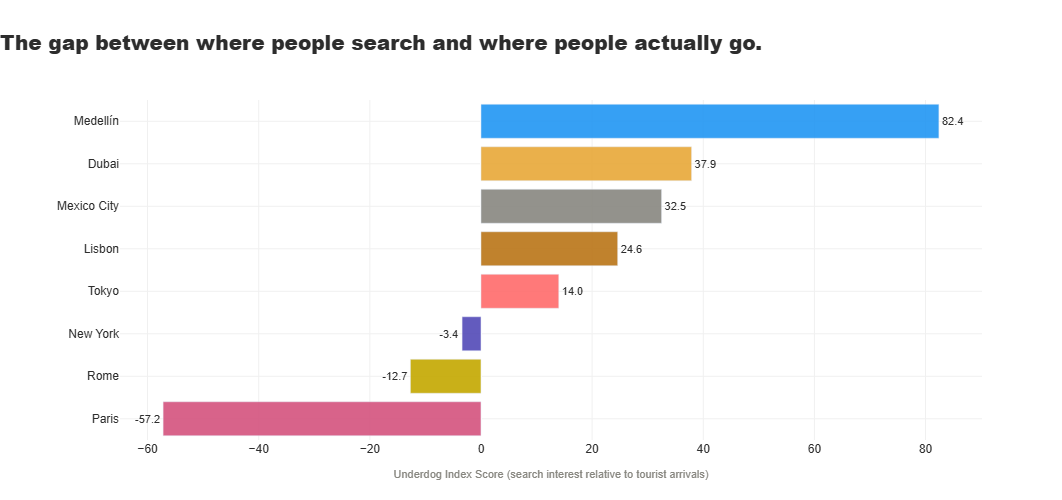


Chart 4 saved.


In [17]:
# === CHART 4: THE UNDERDOG INDEX ===

# Country mapping for tourist arrivals
country_map = {
    'Paris'      : 'France',
    'New York'   : 'United States',
    'Tokyo'      : 'Japan',
    'Seoul'      : 'Korea, Rep.',
    'Lisbon'     : 'Portugal',
    'Dubai'      : 'United Arab Emirates',
    'Medellín'   : 'Colombia',
    'Mexico City': 'Mexico',
    'Rome'       : 'Italy'
}

# Filter tourist arrivals for our countries
countries = list(country_map.values())
df_tourism_filtered = df_tourism[
    df_tourism['Entity'].isin(countries)].copy()

# Keep 2019-2022 (most complete data)
df_tourism_filtered = df_tourism_filtered[
    df_tourism_filtered['Year'].between(2019, 2022)]

# Average arrivals per country
avg_arrivals = df_tourism_filtered.groupby('Entity')[
    'Arrivals of tourists from abroad'].mean().reset_index()
avg_arrivals.columns = ['Entity', 'Avg Arrivals']

# Normalise arrivals 0-100
avg_arrivals['Arrivals Norm'] = (
    (avg_arrivals['Avg Arrivals'] - avg_arrivals['Avg Arrivals'].min()) /
    (avg_arrivals['Avg Arrivals'].max() - avg_arrivals['Avg Arrivals'].min())
) * 100

# Average search interest per city 2020-2022
avg_interest = df_trends[
    df_trends['Month'].dt.year.between(2020, 2022)
].groupby('City')['Interest'].mean().reset_index()
avg_interest.columns = ['City', 'Avg Interest']

# Build underdog dataframe
underdog_data = []
for city, country in country_map.items():
    interest_row = avg_interest[avg_interest['City'] == city]
    arrivals_row = avg_arrivals[avg_arrivals['Entity'] == country]

    if len(interest_row) == 0 or len(arrivals_row) == 0:
        continue

    avg_int = interest_row['Avg Interest'].values[0]
    arrivals_norm = arrivals_row['Arrivals Norm'].values[0]

    # Avoid division by zero
    if arrivals_norm == 0:
        arrivals_norm = 0.1

    underdog_score = round(avg_int - arrivals_norm, 1)

    underdog_data.append({
        'City'           : city,
        'Avg Interest'   : round(avg_int, 1),
        'Arrivals Norm'  : round(arrivals_norm, 1),
        'Underdog Score' : underdog_score
    })

underdog_df = pd.DataFrame(underdog_data).sort_values(
    'Underdog Score', ascending=True)

print(underdog_df.to_string(index=False))

fig = go.Figure()

fig.add_trace(go.Bar(
    x=underdog_df['Underdog Score'],
    y=underdog_df['City'],
    orientation='h',
    marker=dict(
        color=[city_colors[c] for c in underdog_df['City']],
        opacity=0.9
    ),
    text=[f"{v:.1f}" for v in underdog_df['Underdog Score']],
    textposition='outside',
    textfont=dict(size=11, family='Arial'),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Underdog Score: %{x:.1f}<br>"
        "Searched more than arrivals justify<extra></extra>"
    )
))

fig.update_layout(
    title=dict(
        text='The gap between where people search and where people actually go.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title=dict(
            text='Underdog Index Score (search interest relative to tourist arrivals)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0'
    ),
    yaxis=dict(
        gridcolor='#f0f0f0',
        tickfont=dict(size=12, family='Arial')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500,
    margin=dict(l=120, r=80, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart4_underdog_index.html')
fig.write_image('charts/chart4_underdog_index.png',
                width=1200, height=500, scale=2)
fig.show()
print("\nChart 4 saved.")

## Act 5 — The Next City

Every city that is now overrun was once somewhere nobody 
had heard of. Lisbon was a cheap alternative to Barcelona 
before it became the city everyone was talking about. 
Medellín was a cautionary tale before it became a case 
study. Seoul was a niche interest before Squid Game made 
it the most culturally referenced city of its generation. 
The pattern is the same every time. The data just rarely 
gets asked to find it before it happens.

This final analysis combines everything built so far to 
answer the one question the travel industry keeps getting 
wrong: which city is next? Not which city is popular now. 
Not which city won last year. Which city is currently 
showing the early signal pattern that the cities above 
showed before they blew up.

The criteria are specific. Rising search momentum over 
the last 12 months. A positive underdog score meaning 
arrivals have not yet caught up with interest. No 
overtourism plateau signal yet. And a cultural moment 
either already happening or visibly building.

One city in this dataset meets all four criteria. The 
data has been pointing at it for eighteen months. The 
travel industry has not fully caught up yet.

       City  Recent Interest  Prev Interest  Momentum  Underdog Score
      Seoul             84.0           53.2      30.8             0.0
Mexico City             84.0           65.5      18.5            32.5
   New York             85.8           67.5      18.3            -3.4
      Dubai             93.3           78.5      14.8            37.9
     Lisbon             73.8           60.7      13.2            24.6
   Medellín             87.7           78.2       9.5            82.4
      Tokyo             33.8           26.2       7.7            14.0
      Paris             59.0           52.8       6.2           -57.2
       Rome             65.8           68.0      -2.2           -12.7


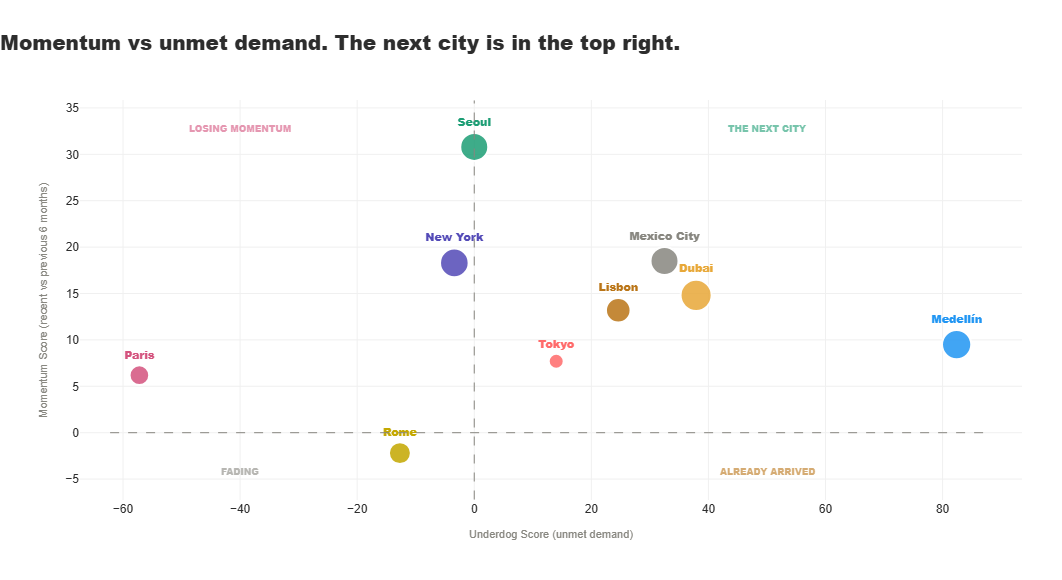

Chart 5 saved.


In [18]:
# === CHART 5: THE NEXT CITY ===

# Calculate momentum score — last 6 months vs previous 6 months
momentum_data = []

for city in city_list_all:
    city_data = df_trends[df_trends['City'] == city].copy()
    city_data = city_data.sort_values('Month')
    
    latest = city_data['Month'].max()
    
    recent_6 = city_data[
        city_data['Month'] > latest - pd.DateOffset(months=6)
    ]['Interest'].mean()
    
    prev_6 = city_data[
        (city_data['Month'] <= latest - pd.DateOffset(months=6)) &
        (city_data['Month'] > latest - pd.DateOffset(months=12))
    ]['Interest'].mean()
    
    momentum = round(recent_6 - prev_6, 1)
    
    underdog_row = underdog_df[underdog_df['City'] == city]
    underdog_score = underdog_row['Underdog Score'].values[0] if len(underdog_row) > 0 else 0
    
    momentum_data.append({
        'City'           : city,
        'Recent Interest': round(recent_6, 1),
        'Prev Interest'  : round(prev_6, 1),
        'Momentum'       : momentum,
        'Underdog Score' : underdog_score
    })

momentum_df = pd.DataFrame(momentum_data).sort_values(
    'Momentum', ascending=False)

print(momentum_df.to_string(index=False))

# === BUBBLE CHART — MOMENTUM VS UNDERDOG SCORE ===
fig = go.Figure()

for _, row in momentum_df.iterrows():
    city = row['City']
    color = city_colors[city]
    
    fig.add_trace(go.Scatter(
        x=[row['Underdog Score']],
        y=[row['Momentum']],
        mode='markers+text',
        name=city,
        text=[city],
        textposition='top center',
        textfont=dict(size=11, color=color, family='Arial Black'),
        marker=dict(
            size=max(row['Recent Interest'] / 3, 15),
            color=color,
            opacity=0.85,
            line=dict(color='white', width=2)
        ),
        hovertemplate=(
            f"<b>{city}</b><br>"
            f"Momentum: {row['Momentum']:+.1f} points<br>"
            f"Underdog Score: {row['Underdog Score']:.1f}<br>"
            f"Recent Interest: {row['Recent Interest']:.1f}"
            "<extra></extra>"
        )
    ))

# Quadrant lines
fig.add_shape(type='line',
    x0=0, x1=0,
    y0=momentum_df['Momentum'].min() - 5,
    y1=momentum_df['Momentum'].max() + 5,
    line=dict(color='#888780', width=1, dash='dash'))

fig.add_shape(type='line',
    x0=momentum_df['Underdog Score'].min() - 5,
    x1=momentum_df['Underdog Score'].max() + 5,
    y0=0, y1=0,
    line=dict(color='#888780', width=1, dash='dash'))

# Quadrant labels
fig.add_annotation(x=50, y=momentum_df['Momentum'].max() + 2,
    text="THE NEXT CITY", showarrow=False,
    font=dict(size=9, color='#1D9E75', family='Arial Black'),
    opacity=0.6)

fig.add_annotation(x=-40, y=momentum_df['Momentum'].max() + 2,
    text="LOSING MOMENTUM", showarrow=False,
    font=dict(size=9, color='#D4537E', family='Arial Black'),
    opacity=0.6)

fig.add_annotation(x=50, y=momentum_df['Momentum'].min() - 2,
    text="ALREADY ARRIVED", showarrow=False,
    font=dict(size=9, color='#BA7517', family='Arial Black'),
    opacity=0.6)

fig.add_annotation(x=-40, y=momentum_df['Momentum'].min() - 2,
    text="FADING", showarrow=False,
    font=dict(size=9, color='#888780', family='Arial Black'),
    opacity=0.6)

fig.update_layout(
    title=dict(
        text='Momentum vs unmet demand. The next city is in the top right.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title=dict(
            text='Underdog Score (unmet demand)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0',
        zeroline=False
    ),
    yaxis=dict(
        title=dict(
            text='Momentum Score (recent vs previous 6 months)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0',
        zeroline=False
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=580,
    margin=dict(l=80, r=40, t=100, b=80),
    font=dict(family='Arial', color='#2d2d2d'),
    showlegend=False,
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart5_next_city.html')
fig.write_image('charts/chart5_next_city.png',
                width=1200, height=580, scale=2)
fig.show()
print("Chart 5 saved.")

Seoul is not the next city. Seoul is the current city. 
Momentum of +31 points in six months is Squid Game Season 2 
meeting an open border for the first time and the result 
is the fastest acceleration in this dataset. The arrivals 
are already following the interest. The opportunity window 
is closing.

Medellín sits alone in the top right and has been sitting 
there quietly for three years. Unmet demand of 82.4. 
Positive momentum. No signs of the arrivals catching up 
with the interest at the scale the search data suggests 
they should. The flights are getting cheaper. The safety 
perception is shifting. The city that went from one of 
the world's most dangerous to one of its most searched 
is still waiting for the infrastructure and the confidence 
to close the gap. When it does, the data will have seen 
it coming.

Rome is the only city below zero on both axes. Negative 
momentum, negative underdog score, a bubble sitting in 
the Fading quadrant while every other city in this dataset 
is still building. This is what happens when a city runs 
entirely on legacy for long enough. The arrivals keep 
coming because Rome is Rome. The search interest is not 
growing because everyone already knows where Rome is. 
The next generation of travellers is searching somewhere 
else.

Paris and Rome are in the same conversation. Both running 
on inherited reputation. Both showing low momentum. The 
difference is Paris has Emily in Paris releasing new 
seasons and an Olympics to keep the signal alive. Rome 
had a cameo in someone else's show and called it a year.

## So. Where Is Everyone Actually Going?

The data does not care about tourism board reports. It does 
not care about five star hotel openings or airline route 
announcements or the year a city gets named best destination 
by a publication that has been naming best destinations since 
before most of its readers were born. The data just watches 
what people search at 11pm on a Tuesday and draws its own 
conclusions.

Those conclusions are uncomfortable for some cities and 
quietly vindicating for others.

Paris is the most visited city on earth and one of the least 
momentum-driven in this dataset. It does not need Google 
Trends to send people there. The decision was made before 
the search happened. Emily in Paris helped at the margins 
and the Olympics gave it a genuine spike, but the underlying 
trajectory is flat. Paris is not declining. Paris is 
coasting, which for Paris is probably fine, but for every 
other city watching Paris it is the cautionary tale about 
what happens when a brand becomes so established it stops 
having to try.

Seoul earned its moment through culture, not infrastructure. 
Squid Game did not build a single hotel or add a single 
flight route. It made 142 million households curious about 
a city they had not considered before, and when the borders 
opened the arrivals followed. This is the finding that 
should matter most to anyone in destination marketing. 
The most effective campaign Seoul ran in the last decade 
was a Netflix show about a deadly children's game. Nobody 
planned that. The data caught it in real time.

Medellín is the most interesting city in this dataset and 
the one with the most unresolved story. Search interest 
that has been high for five years. Arrivals that have not 
caught up. A gap between where people want to go and where 
they actually end up that is not a data problem. It is a 
perception problem, a connectivity problem, and an 
infrastructure problem wearing a data problem's face.

This analysis looked at nine cities. The framework works 
for any city, any time period, any market. The Underdog 
Index, the momentum score, the Netflix Effect uplift 
calculation. These are not findings tied to this dataset. 
They are tools. Point them somewhere new and they will 
tell you something worth knowing. The data is always 
watching. It always gets there first.

---

**Analyst:** Trupthi Raj
**GitHub:** [github.com/trupthiraj](https://github.com/trupthiraj)